# Результаты экспериментов (n=220, RGB + NYPL pool)

Загружает все `data/eval/results/final/metrics_triad_*_n220.json` и строит:

- сводную таблицу с bootstrap CI95;
- per-source subset breakdown (rgb anchor n=20 vs nypl pool n=200);
- retrieval R@k (text→image);
- paired bootstrap p-values vs baseline;
- top-5 per-image выигрыши и просадки;
- качественные примеры.

Исторические n=20 results лежат рядом в `final/` без суффикса; здесь не показываются.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
from scripts.eval_stats import bootstrap_ci, paired_bootstrap

PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / 'data' / 'eval' / 'results' / 'final'
print('Results dir:', RESULTS_DIR)

Results dir: /Users/yanakhalitova/workspace/project-seminar/tsu-image-description/data/eval/results/final


## 1. Загрузка n=220 runs

In [2]:
RUN_LABELS = {
    'metrics_triad_baseline_n220.json':                          'baseline',
    'metrics_triad_E-1_blip_large_n220.json':                    'E-1 (BLIP-large)',
    'metrics_triad_E-16_drop_theme_n220.json':                   'E-16 (drop theme+mood)',
    'metrics_triad_E-1+16_blip_large_drop_theme_n220.json':      'E-1+E-16 (combined)',
}
RUN_ORDER = ['baseline', 'E-1 (BLIP-large)', 'E-16 (drop theme+mood)', 'E-1+E-16 (combined)']

runs = {}
for path in sorted(RESULTS_DIR.glob('metrics_triad_*_n220.json')):
    label = RUN_LABELS.get(path.name)
    if label:
        runs[label] = json.loads(path.read_text(encoding='utf-8'))

# Reorder
runs = {k: runs[k] for k in RUN_ORDER if k in runs}

for label, r in runs.items():
    n = r['summary']['num_examples']
    print(f'  - {label}  (n={n})')

  - baseline  (n=220)
  - E-1 (BLIP-large)  (n=220)
  - E-16 (drop theme+mood)  (n=220)
  - E-1+E-16 (combined)  (n=220)


## 2. Сводная таблица: aggregate + by-source breakdown

**rgb** — 20 открыток из РГБ/НЭБ (с weak references). **nypl** — 200 случайно сэмплированных NYPL-открыток (disjoint от training splits).

Метрика: `CLIPScore_RU(image, archive_description_ru)` через `M-CLIP/XLM-Roberta-Large-Vit-B-32`.

In [3]:
def per_item_archive(run, source=None):
    return [
        it['scores']['CLIPScore_RU_archive_ru']
        for it in run['per_item']
        if it['scores'].get('CLIPScore_RU_archive_ru') is not None
        and (source is None or it.get('source') == source)
    ]

def summarize(run):
    s = run['summary']
    all_vals = per_item_archive(run)
    lo, hi = bootstrap_ci(all_vals, n_iter=1000, conf=0.95, seed=42)
    return {
        'n (all)':                  s['num_examples'],
        'CLIPScore_RU (all)':       float(np.mean(all_vals)),
        'CI95 (all)':               f'[{lo:.3f}, {hi:.3f}]',
        'rgb (n=20)':               s['by_source']['rgb']['CLIPScore_RU_archive_ru'],
        'nypl (n=200)':             s['by_source']['nypl']['CLIPScore_RU_archive_ru'],
        'R@1 (t2i)':                s['retrieval']['t2i']['R@1'],
        'R@5 (t2i)':                s['retrieval']['t2i']['R@5'],
        'R@10 (t2i)':               s['retrieval']['t2i']['R@10'],
        'mean rank (t2i)':          s['retrieval']['mean_rank_t2i'],
        'Latency s/img':            s['latency']['mean_sec'],
    }

table = pd.DataFrame({label: summarize(r) for label, r in runs.items()}).T
table.index.name = 'run'
table.round(4)

,n (all),CLIPScore_RU (all),CI95 (all),rgb (n=20),nypl (n=200),R@1 (t2i),R@5 (t2i),R@10 (t2i),mean rank (t2i),Latency s/img
run,,,,,,,,,,
baseline,220,0.28043,"[0.276, 0.284]",0.325384,0.275935,0.159091,0.377273,0.463636,36.818182,0.721811
E-1 (BLIP-large),220,0.288341,"[0.283, 0.294]",0.331256,0.284049,0.213636,0.418182,0.490909,31.459091,0.887291
E-16 (drop theme+mood),220,0.28649,"[0.282, 0.291]",0.32616,0.282523,0.140909,0.404545,0.536364,27.75,0.713456
E-1+E-16 (combined),220,0.297668,"[0.293, 0.303]",0.334105,0.294024,0.240909,0.477273,0.604545,21.318182,0.887792


## 3. CLIPScore_RU(archive) с 95% bootstrap CI

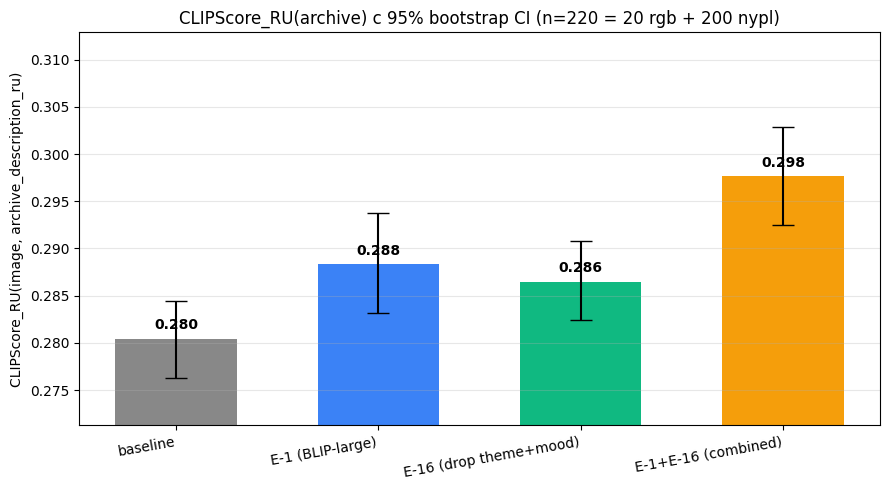

In [4]:
ci_rows = []
for label, r in runs.items():
    vals = per_item_archive(r)
    m = float(np.mean(vals))
    lo, hi = bootstrap_ci(vals, n_iter=1000, conf=0.95, seed=42)
    ci_rows.append({'run': label, 'mean': m, 'ci_lo': lo, 'ci_hi': hi})
ci_df = pd.DataFrame(ci_rows)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(ci_df))
colors = ['#888888', '#3b82f6', '#10b981', '#f59e0b']
ax.bar(
    x, ci_df['mean'],
    yerr=[ci_df['mean'] - ci_df['ci_lo'], ci_df['ci_hi'] - ci_df['mean']],
    capsize=8, color=colors[:len(ci_df)], width=0.6,
)
ax.set_xticks(x)
ax.set_xticklabels(ci_df['run'], rotation=10, ha='right')
ax.set_ylabel('CLIPScore_RU(image, archive_description_ru)')
ax.set_title(f'CLIPScore_RU(archive) с 95% bootstrap CI (n=220 = 20 rgb + 200 nypl)')
ax.grid(axis='y', alpha=0.3)
ymin = ci_df['ci_lo'].min() - 0.005
ymax = ci_df['ci_hi'].max() + 0.01
ax.set_ylim(ymin, ymax)
for i, row in ci_df.iterrows():
    ax.text(i, row['mean'] + 0.001, f"{row['mean']:.3f}", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Per-source subset breakdown

Эта диаграмма показывает, **сходятся ли тренды на rgb anchor и nypl pool**. Если да — улучшения переносятся между доменами; если нет — есть domain-specific эффекты.

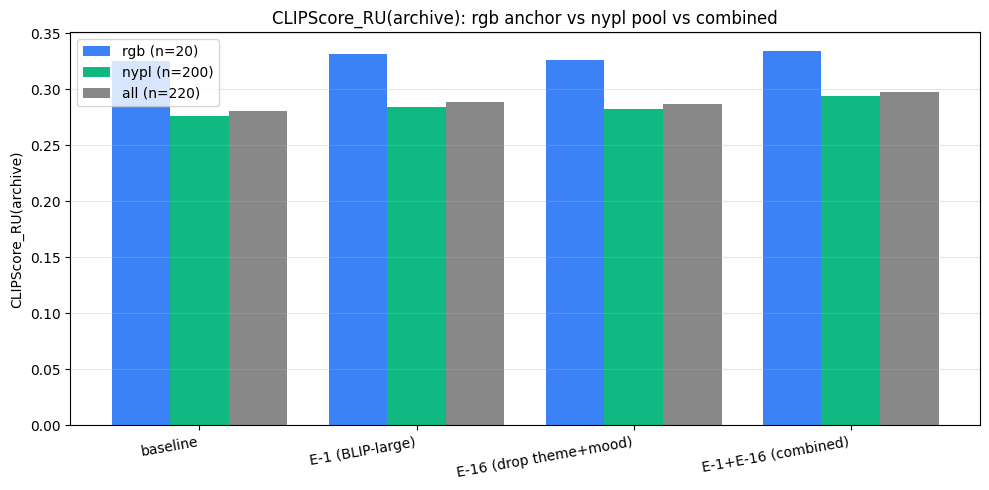

,run,rgb (n=20),nypl (n=200),all (n=220)
0,baseline,0.3254,0.2759,0.2804
1,E-1 (BLIP-large),0.3313,0.2840,0.2883
2,E-16 (drop theme+mood),0.3262,0.2825,0.2865
3,E-1+E-16 (combined),0.3341,0.2940,0.2977


In [5]:
src_rows = []
for label, r in runs.items():
    s = r['summary']['by_source']
    src_rows.append({
        'run': label,
        'rgb (n=20)':   s['rgb']['CLIPScore_RU_archive_ru'],
        'nypl (n=200)': s['nypl']['CLIPScore_RU_archive_ru'],
        'all (n=220)':  r['summary']['metrics']['CLIPScore_RU_archive_ru'],
    })
src_df = pd.DataFrame(src_rows)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(src_df))
w = 0.27
ax.bar(x - w, src_df['rgb (n=20)'],   w, label='rgb (n=20)',   color='#3b82f6')
ax.bar(x,     src_df['nypl (n=200)'], w, label='nypl (n=200)', color='#10b981')
ax.bar(x + w, src_df['all (n=220)'],  w, label='all (n=220)',  color='#888888')
ax.set_xticks(x)
ax.set_xticklabels(src_df['run'], rotation=10, ha='right')
ax.set_ylabel('CLIPScore_RU(archive)')
ax.set_title('CLIPScore_RU(archive): rgb anchor vs nypl pool vs combined')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

src_df.round(4)

## 5. Retrieval R@k (text → image)

Это **прокси для архивного поиска**: пользователь набирает русское описание, система ищет картинку из пула 220. Случайный baseline для R@1 = 1/220 ≈ 0.0045.

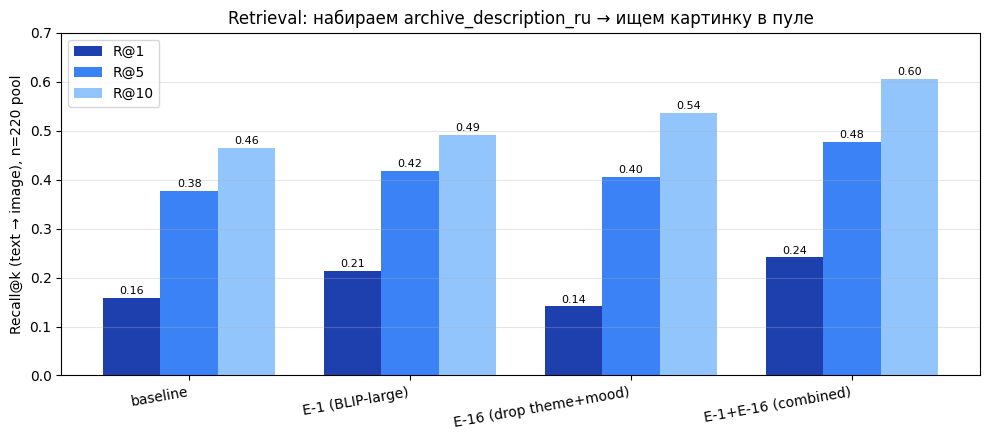

,run,R@1,R@5,R@10
0,baseline,0.1591,0.3773,0.4636
1,E-1 (BLIP-large),0.2136,0.4182,0.4909
2,E-16 (drop theme+mood),0.1409,0.4045,0.5364
3,E-1+E-16 (combined),0.2409,0.4773,0.6045


In [6]:
ret_rows = []
for label, r in runs.items():
    s = r['summary']['retrieval']
    ret_rows.append({
        'run':  label,
        'R@1':  s['t2i']['R@1'],
        'R@5':  s['t2i']['R@5'],
        'R@10': s['t2i']['R@10'],
    })
ret_df = pd.DataFrame(ret_rows)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(ret_df))
w = 0.26
ax.bar(x - w, ret_df['R@1'],  w, label='R@1',  color='#1e40af')
ax.bar(x,     ret_df['R@5'],  w, label='R@5',  color='#3b82f6')
ax.bar(x + w, ret_df['R@10'], w, label='R@10', color='#93c5fd')
ax.set_xticks(x)
ax.set_xticklabels(ret_df['run'], rotation=10, ha='right')
ax.set_ylabel('Recall@k (text → image), n=220 pool')
ax.set_title('Retrieval: набираем archive_description_ru → ищем картинку в пуле')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 0.7)
for i, row in ret_df.iterrows():
    for off, k in zip([-w, 0, w], ['R@1', 'R@5', 'R@10']):
        ax.text(i + off, row[k] + 0.008, f"{row[k]:.2f}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

ret_df.round(4)

## 6. Paired bootstrap p-value vs baseline

Проверка значимости Δ CLIPScore_RU(archive) против baseline. n=220 даёт уже формально значимые результаты на α=0.1, в отличие от n=20.

In [7]:
baseline_vals = per_item_archive(runs['baseline'])
p_rows = []
for label, r in runs.items():
    if label == 'baseline': continue
    cand_vals = per_item_archive(r)
    delta = float(np.mean(cand_vals) - np.mean(baseline_vals))
    p = paired_bootstrap(baseline_vals, cand_vals, n_iter=1000, seed=42)
    p_rows.append({
        'run':      label,
        'Δ mean':   delta,
        'p (bootstrap)': p,
        'sig @0.1': 'yes' if p < 0.1 else 'no',
    })
pd.DataFrame(p_rows).round(4)

,run,Δ mean,p (bootstrap),sig @0.1
0,E-1 (BLIP-large),0.0079,0.0,yes
1,E-16 (drop theme+mood),0.0061,0.0,yes
2,E-1+E-16 (combined),0.0172,0.0,yes


## 7. Где самые большие per-image сдвиги (E-1+E-16 vs baseline)?

Top-5 биггест wins и losses — потенциальный материал для качественного анализа в тезисе.

In [8]:
best_label = RUN_ORDER[-1]  # E-1+E-16
best_items = runs[best_label]['per_item']
baseline_items = runs['baseline']['per_item']

deltas = []
for b_it, bs_it in zip(best_items, baseline_items):
    d = b_it['scores']['CLIPScore_RU_archive_ru'] - bs_it['scores']['CLIPScore_RU_archive_ru']
    deltas.append({
        'image':      Path(b_it['image_path']).name,
        'source':     b_it.get('source', 'rgb'),
        'baseline':   bs_it['scores']['CLIPScore_RU_archive_ru'],
        f'{best_label}': b_it['scores']['CLIPScore_RU_archive_ru'],
        'delta':      d,
    })
delta_df = pd.DataFrame(deltas)

print('=== Top 5 биггест wins (E-1+E-16 vs baseline) ===')
wins = delta_df.nlargest(5, 'delta')
display(wins.round(4))

print('\n=== Top 5 биггест losses ===')
losses = delta_df.nsmallest(5, 'delta')
display(losses.round(4))

print(f'\nИтого: {(delta_df["delta"] > 0).sum()}/{len(delta_df)} картинок улучшились,')
print(f'        {(delta_df["delta"] < 0).sum()}/{len(delta_df)} ухудшились,')
print(f'        средний Δ = {delta_df["delta"].mean():+.4f}')

=== Top 5 биггест wins (E-1+E-16 vs baseline) ===


,image,source,baseline,E-1+E-16 (combined),delta
74,3be77dd0-54d6-0137-5155-79bcf8ac3134.jpg,nypl,0.2186,0.3541,0.1355
70,310e5050-4f1d-0137-39a7-39c5ab556270.jpg,nypl,0.2454,0.3603,0.1149
98,510d47db-bc92-a3d9-e040-e00a18064a99.jpg,nypl,0.2624,0.3744,0.1120
4,postcard_5.jpg,rgb,0.2716,0.3600,0.0885
59,22d98420-54d6-0137-3b28-5dc5c47c3140.jpg,nypl,0.2724,0.3580,0.0856



=== Top 5 биггест losses ===


,image,source,baseline,E-1+E-16 (combined),delta
31,0bc8b730-5fce-0137-e053-2dbe10d11a50.jpg,nypl,0.2572,0.2070,-0.0502
32,0be98850-5fce-0137-624f-79c558cc7e20.jpg,nypl,0.2572,0.2070,-0.0502
33,0eda2e20-5fce-0137-b89d-02d64ec962a9.jpg,nypl,0.2572,0.2070,-0.0502
56,1ea29040-a002-0137-cea5-0bc4aa8f3a9a.jpg,nypl,0.2572,0.2070,-0.0502
6,postcard_7.jpg,rgb,0.3457,0.3066,-0.0390



Итого: 166/220 картинок улучшились,
        54/220 ухудшились,
        средний Δ = +0.0172


## 8. Качественные примеры — где описания стали лучше и хуже

Показываем биггест win и биггест loss + 3 примера из rgb anchor.

In [9]:
def show_example(idx, runs, baseline_items, best_items):
    print(f"=== {Path(baseline_items[idx]['image_path']).name}  (source={baseline_items[idx].get('source')}) ===")
    if baseline_items[idx]['reference_ru']:
        print(f"  reference: {baseline_items[idx]['reference_ru']}")
    for label, r in runs.items():
        it = r['per_item'][idx]
        score = it['scores']['CLIPScore_RU_archive_ru']
        print(f"  [{score:.3f}] {label}:")
        print(f"          {it['archive_ru']}")
    print()

# биггест win
win_idx = int(delta_df['delta'].idxmax())
print(f'### Biggest win (Δ = {delta_df.loc[win_idx, "delta"]:+.4f})')
show_example(win_idx, runs, baseline_items, best_items)

# биггест loss
loss_idx = int(delta_df['delta'].idxmin())
print(f'### Biggest loss (Δ = {delta_df.loc[loss_idx, "delta"]:+.4f})')
show_example(loss_idx, runs, baseline_items, best_items)

# 3 rgb anchor
print('### 3 rgb anchor examples (postcards 1-3)')
for i in range(3):
    show_example(i, runs, baseline_items, best_items)

### Biggest win (Δ = +0.1355)
=== 3be77dd0-54d6-0137-5155-79bcf8ac3134.jpg  (source=nypl) ===
  [0.219] baseline:
          Плакат в стиле винтажная иллюстрация. На изображении: Книгу с красной обложкой и черным титулом. Предположительно, это праздничная сцена. Общее настроение изображения можно охарактеризовать как ностальгическое.
  [0.320] E-1 (BLIP-large):
          Плакат в стиле винтажная иллюстрация. На изображении: На ней есть книга с постером турнира для гольфа.. Предположительно, это праздничная сцена. Общее настроение изображения можно охарактеризовать как ностальгическое.
  [0.261] E-16 (drop theme+mood):
          Плакат в стиле винтажная иллюстрация. На изображении: Книгу с красной обложкой и черным титулом.
  [0.354] E-1+E-16 (combined):
          Плакат в стиле винтажная иллюстрация. На изображении: На ней есть книга с постером турнира для гольфа..

### Biggest loss (Δ = -0.0502)
=== 0bc8b730-5fce-0137-e053-2dbe10d11a50.jpg  (source=nypl) ===
  [0.257] baseline:
       